In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
from matplotlib import pyplot as plt
# from quantpilot.features.technical_indicators import FeatureTechnicalIndicators
from quantpilot.features.feature_selection import plot_feature_importance, select_features
# from quantpilot.features.ml_features import add_hmm_features, add_rolling_kmeans_cluster_feature, add_nlp_sentiment_score
from quantpilot.features.ml_features import add_hmm_features, add_nlp_sentiment_score

In [6]:
# Load sample data
df = pd.read_csv('../../experimental/datasets/btc_data_with_target.csv', parse_dates=['datetime'], index_col='datetime')

df = add_nlp_sentiment_score(
    df,
    sentiment_file_path='../../experimental/datasets/bitcoin_sentiments_21_24.csv',
    datetime_col='datetime'
)

# Display data info
df.head()

,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,close,high,low,open,volume,start_time_open_interest,open_interest,future_return,target,sentiment
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,5003.956097,5539.122307,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2,0
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,5321.391317,5673.675553,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0,0
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,4851.922211,5336.407163,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2,0
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,4996.738882,5266.074097,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2,0
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,5238.567725,5270.315869,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2,0


In [9]:
# 2. Basic technical indicators
print("\n2. Adding basic technical indicators...")
new_df = df.copy()
# feature_technical = FeatureTechnicalIndicators(new_df, price_col='close')

# # Add individual technical indicators
# feature_technical.add_ema([5, 8, 13])
# feature_technical.add_sma([50, 200])
# feature_technical.add_rsi([14])
# feature_technical.add_macd(fast_window=12, slow_window=26, signal_window=9)
# feature_technical.add_price_change([1])
# feature_technical.add_bollinger_bands([20], num_std=2)

# # Add all features at once
# # feature_technical.add_all_features()

# # Show added features by comparing with original DataFrame
# added_features = list(set(new_df.columns) - set(df.columns))
# print(f"Added {len(added_features)} features: {', '.join(added_features)}")
new_df = new_df.dropna()
new_df.head()



2. Adding basic technical indicators...


,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,close,high,low,open,volume,start_time_open_interest,open_interest,future_return,target,sentiment
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,5003.956097,5539.122307,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2,0
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,5321.391317,5673.675553,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0,0
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,4851.922211,5336.407163,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2,0
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,4996.738882,5266.074097,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2,0
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,5238.567725,5270.315869,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2,0


In [ ]:
print("\n3. Adding HMM cluster features...")

# All the features except target
# feature_cols = list(set(new_df.columns) - set(['target']))
feature_cols = [
    "addresses_count_active",           # Reflects network activity
    "addresses_count_receiver",         # Indicates demand-side user activity
    "addresses_count_sender",           # Indicates spending / selling behavior
    "blockreward_usd",                  # Incentivization for miners (can affect sell pressure)
    "fees_transaction_mean_usd",        # Reflects network congestion and user willingness to pay
    "miner_supply_ratio",               # Miner-held supply — key for sell pressure
    "exchange_supply_ratio",            # Reflects asset availability for trading on exchanges
    "transactions_count_inflow",        # Potential incoming pressure (supply side)
    "transactions_count_outflow",       # Potential withdrawals (holding / bullish behavior)
    "tokens_transferred_mean",          # Reflects transaction volume per user
    "tokens_transferred_total"          # Overall market activity signal
]



# Select features for HMM (Hidden Markov Model)
new_df = add_hmm_features(new_df, feature_cols, n_components=3, n_iter=2000, )

# Add KMeans cluster features using CNN (Rolling KMeans Clustering)
# new_df = add_rolling_kmeans_cluster_feature(new_df, feature_cols, n_clusters=3)

new_df


3. Adding HMM cluster features...


Model is not converging.  Current: -2990698.645919635 is not greater than -2990698.645513144. Delta is -0.00040649110451340675


,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,high,low,open,volume,start_time_open_interest,open_interest,future_return,target,sentiment,hmm_state
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,5539.122307,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2,0,1
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,5673.675553,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0,0,1
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,5336.407163,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2,0,1
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,5266.074097,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2,0,1
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,5270.315869,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 18:00:00,1743444000000,1.137575e+14,1743444000000,0.162283,1743444000000,76251,38448,47636,1743444000000,0.846697,...,83559.225160,82725.931173,82732.416876,989.551559,1743444000000,7.737655e+09,-0.010128,0,0,2
2025-03-31 19:00:00,1743447600000,1.137575e+14,1743447600000,0.161615,1743447600000,59154,29711,36980,1743447600000,0.997602,...,83457.590765,82382.628052,83300.876330,1635.480392,1743447600000,7.628593e+09,-0.000035,1,0,2
2025-03-31 20:00:00,1743451200000,1.137575e+14,1743451200000,0.161152,1743451200000,71194,36194,44509,1743451200000,0.983015,...,82850.365222,82365.878186,82437.212737,719.056901,1743451200000,7.613252e+09,0.001304,2,0,2



Unique values in 'hmm_state' column:
hmm_state
2    21495
0    11868
1    10733
Name: count, dtype: int64


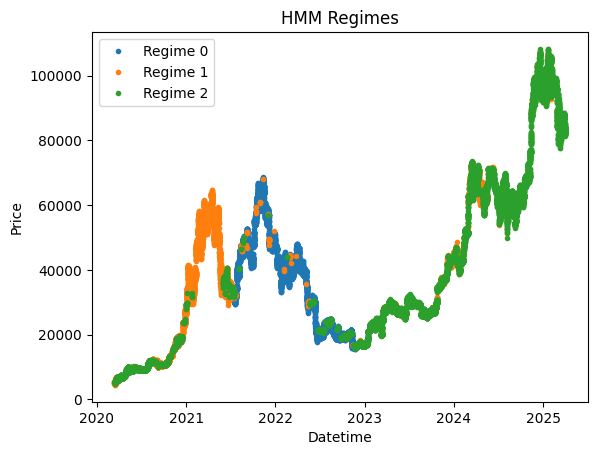

In [32]:
# find unique values in the 'hmm_state' column and their counts
unique_values = new_df['hmm_state'].value_counts()
print("\nUnique values in 'hmm_state' column:")
print(unique_values)

# Plot Hidden Markov Model (HMM) regimes
for i in range(3):
    plt.plot(new_df[new_df['hmm_state'] == i].index,
                new_df[new_df['hmm_state'] == i]['close'], 
                '.',
                label=f"Regime {i}")
    plt.legend()
    
plt.title("HMM Regimes")
plt.xlabel("Datetime")
plt.ylabel("Price")   
plt.show()

# # Plot KMeans clusters
# for i in range(3):
#     plt.plot(new_df[new_df['kmeans_cluster'] == i].index,
#                 new_df[new_df['kmeans_cluster'] == i]['close'], 
#                 '.',
#                 label=f"Cluster {i}")
#     plt.legend()
    
# plt.title("KMeans Cluster")
# plt.xlabel("Datetime")
# plt.ylabel("Price")   
    
# plt.show()


4. Feature selection...

Top Features:
                             feature  importance
                    taker_sell_ratio    0.056899
                     taker_buy_ratio    0.056899
                taker_buy_sell_ratio    0.056261
coinbase_premium_index_usdt_adjusted    0.045266
  coinbase_premium_gap_usdt_adjusted    0.034479
              addresses_count_active    0.017555
              addresses_count_sender    0.017535
                         blockreward    0.016074
                   long_liquidations    0.014452
            addresses_count_receiver    0.013599
             tokens_transferred_mean    0.013381
                   taker_sell_volume    0.010776
                     blockreward_usd    0.009748
            tokens_transferred_total    0.009133
                  short_liquidations    0.008818
              short_liquidations_usd    0.007801
               long_liquidations_usd    0.007127
           fees_transaction_mean_usd    0.006282
               exchange_suppl

,taker_sell_ratio,taker_buy_ratio,taker_buy_sell_ratio,coinbase_premium_index_usdt_adjusted,coinbase_premium_gap_usdt_adjusted,addresses_count_active,addresses_count_sender,blockreward,long_liquidations,addresses_count_receiver,...,taker_sell_volume,blockreward_usd,tokens_transferred_total,short_liquidations,short_liquidations_usd,long_liquidations_usd,fees_transaction_mean_usd,exchange_supply_ratio,hmm_state,close
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,0.496592,0.503408,1.013725,3.161427,149.000988,48038,26511,77.841484,2366.709000,26544,...,1.998601e+08,3.241085e+05,97403.833146,2083.077000,9.372163e+06,1.010010e+07,0.949446,0.015152,1,5003.956097
2020-03-13 03:00:00,0.485980,0.514020,1.057699,1.171980,58.800356,18207,7846,26.791044,1075.036000,12110,...,1.537000e+08,1.418812e+05,60441.379739,823.359000,4.294425e+06,5.538497e+06,1.999995,0.015113,1,5321.391317
2020-03-13 04:00:00,0.522829,0.477171,0.912672,-0.079106,-3.715534,54478,23715,78.638468,1297.364000,37906,...,1.009769e+08,3.991776e+05,144922.551423,128.929000,6.305205e+05,6.312496e+06,1.355277,0.014982,1,4851.922211
2020-03-13 05:00:00,0.505362,0.494638,0.978780,-0.238740,-11.775611,55117,27065,78.031384,1626.762000,34953,...,1.073788e+08,3.943265e+05,101484.389205,328.634000,1.636558e+06,8.126823e+06,1.209814,0.015025,1,4996.738882
2020-03-13 06:00:00,0.493174,0.506826,1.027683,0.451102,23.310530,31961,18053,52.144150,1085.844000,18160,...,7.877188e+07,2.621847e+05,55781.232528,214.322000,1.079010e+06,5.408272e+06,1.190944,0.014988,1,5238.567725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 18:00:00,0.488277,0.511723,1.048020,-0.006184,-5.150837,76251,47636,22.152889,0.097000,38448,...,3.424566e+08,1.844733e+06,33988.312437,3.475084,2.901848e+05,8.062109e+03,1.141034,0.028848,2,83287.446732
2025-03-31 19:00:00,0.531443,0.468557,0.881669,-0.004337,-3.576791,59154,36980,19.119721,7.523869,29711,...,3.754510e+08,1.587521e+06,29340.025782,0.002000,1.661709e+02,6.201776e+05,2.066954,0.028851,2,82443.899978
2025-03-31 20:00:00,0.469972,0.530028,1.127787,-0.000067,-0.055302,71194,44509,31.509539,0.464244,36194,...,2.203566e+08,2.603416e+06,62687.893816,0.283000,2.349374e+04,3.809767e+04,1.162708,0.028877,2,82441.035723


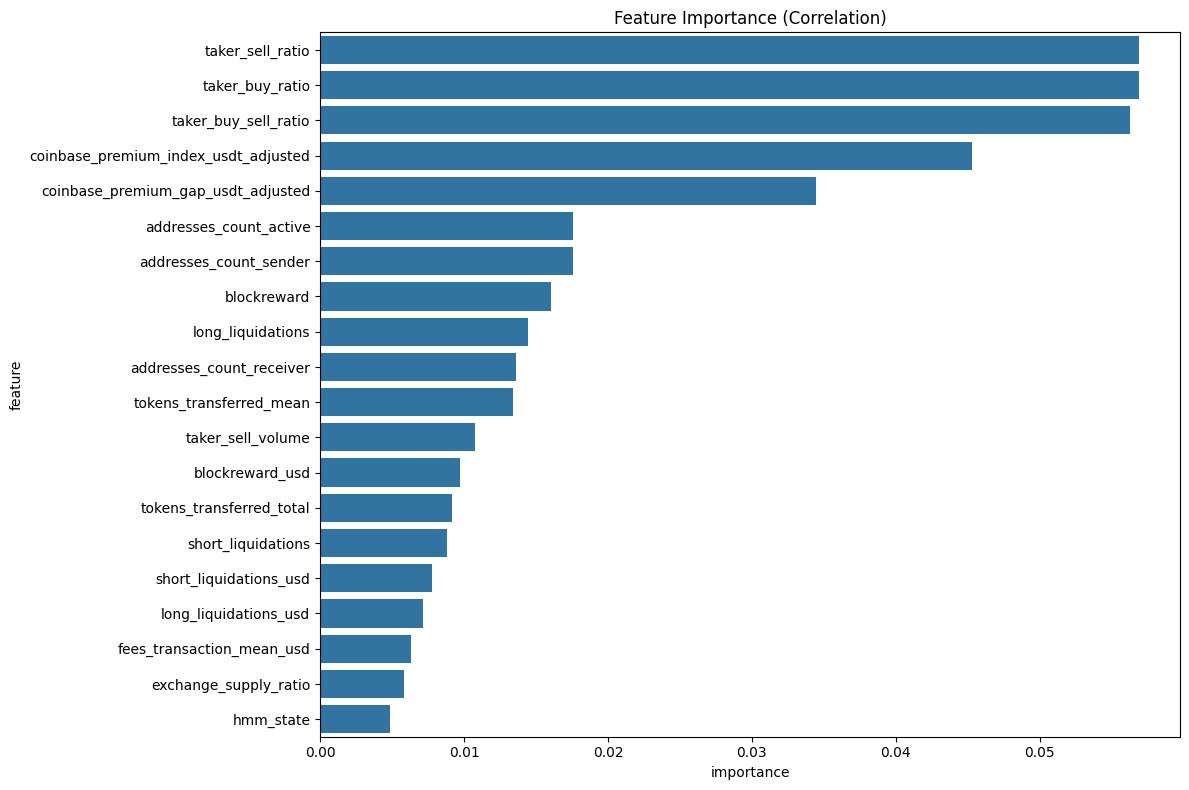

In [33]:
# 4. Feature selection
### NOTE: the target column should be the one you want to predict, i.e., 'buy' or 'sell' signal
print("\n4. Feature selection...") 
new_df2 = new_df.copy()

target_col = 'target'
X = new_df2.drop(columns=[target_col, 'future_return'])
top10_all = plot_feature_importance(new_df2, target_col=target_col, feature_cols=list(X.columns), top_n=20, save_img_path='feature_importance_all.png', method='correlation')
print(f"Top 20 features (all): {top10_all}")

# Select features based on correlation
new_df2 = select_features(new_df2, features=top10_all + ['close'])
new_df2

In [ ]:
# Save the new DataFrame to a CSV file
# new_df.to_csv('../../experimental/datasets/btc_data_with_target_latest.csv', index=True)